In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('../data/netflix_catalogue.csv')

print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())

Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64


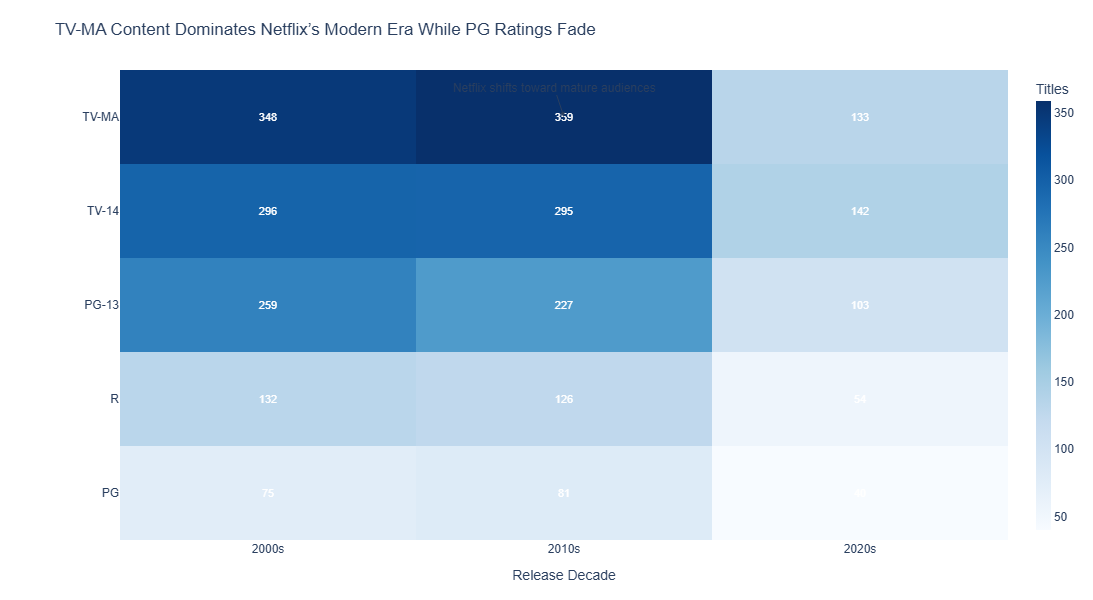

In [2]:
# ============================================================
# TASK 1 — HEATMAP: Content by Rating and Release Decade
# ============================================================

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Keep only major ratings
ratings_keep = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

heat_df = df[df['rating'].isin(ratings_keep)]

# Group data
rating_decade = (
    heat_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

# Pivot table
pivot = rating_decade.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

# Sort ratings by total count
pivot = pivot.loc[
    pivot.sum(axis=1).sort_values(ascending=False).index
]

# ── Plotly Express base chart ───────────────────────────────
fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto',
    width=1000,
    height=600,
    labels={'color': 'Number of Titles'}
)

# ── Styling ─────────────────────────────────────────────────
fig.update_traces(
    textfont=dict(size=11, color='white'),
    hovertemplate='<b>%{y}</b> — %{x}<br>Titles: %{z}<extra></extra>'
)

fig.update_layout(
    title='TV-MA Content Dominates Netflix’s Modern Era While PG Ratings Fade',
    font=dict(family='Arial', size=12),
    margin=dict(l=120, r=40, t=70, b=60),
    coloraxis_colorbar=dict(
        title='Titles',
        thickness=15
    ),
    xaxis=dict(title='Release Decade'),
    yaxis=dict(title='')
)

# Annotation
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Netflix shifts toward mature audiences',
    showarrow=True,
    arrowhead=2
)

fig.show()


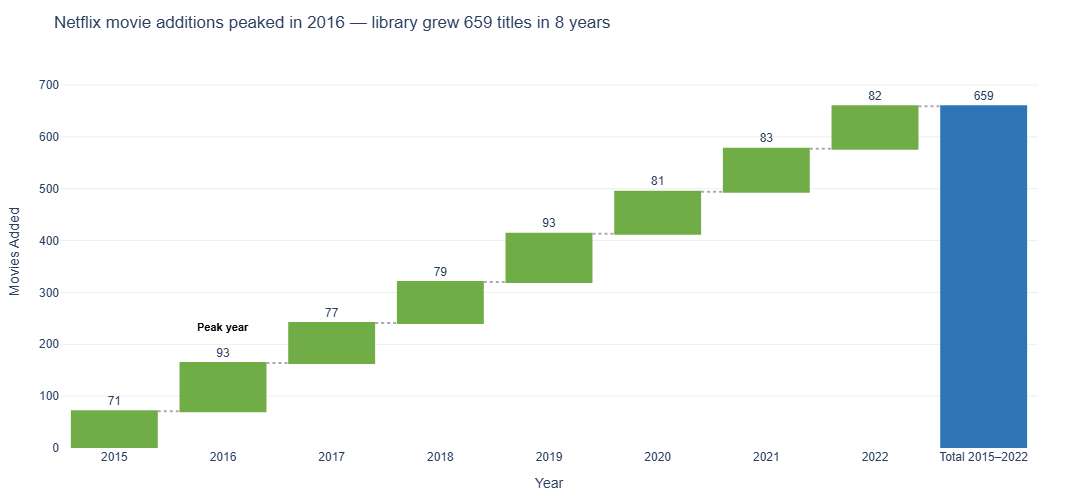

In [3]:
movies = df[df['type'] == 'Movie'].copy()

adds = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='new_titles')
)
adds = adds.loc[adds['added_year'].between(2015, 2022)].copy()

cumulative = adds['new_titles'].sum()

x_vals  = adds['added_year'].astype(str).tolist() + ['Total 2015–2022']
y_vals  = adds['new_titles'].tolist() + [cumulative]
measure = ['relative'] * len(adds) + ['total']

trace = go.Waterfall(
    x=x_vals,
    y=y_vals,
    measure=measure,
    connector=dict(line=dict(color='#AAAAAA', dash='dot')),
    increasing=dict(marker_color='#70AD47'),   # green: additions
    totals=dict(marker_color='#2E75B6'),        # blue: cumulative total bar
    texttemplate='%{y:,}',
    textposition='outside',
)

fig = go.Figure(data=[trace])

peak_year  = adds.loc[adds['new_titles'].idxmax(), 'added_year']
peak_idx = adds['added_year'].astype(str).tolist().index(str(peak_year))
# Cumulative total up to and including peak year — this is where the top of the bar sits
peak_cumulative_y = adds.loc[adds['added_year'] <= peak_year, 'new_titles'].sum()

fig.add_annotation(
    x=peak_idx,
    y=peak_cumulative_y + 70,          # just above the top of the bar
    text='<b>Peak year</b>',
    font=dict(color='black', size=11, family='Arial'),
    showarrow=False
)

fig.update_layout(
    title=f'Netflix movie additions peaked in {peak_year} — library grew {cumulative:,} titles in 8 years',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    showlegend=False,
    margin=dict(l=60, r=40, t=55, b=40),
    height=500,
)
fig.update_xaxes(title='Year', showgrid=False)
fig.update_yaxes(
    title='Movies Added',
    gridcolor='#EEEEEE',
    range=[0, cumulative * 1.15],      # explicit headroom so nothing gets clipped
)

fig.show()